# Analyse de Performances E-commerce

## Projet académique - Data Analytics

**Objectif** : Analyser le comportement des visiteurs et optimiser le tunnel de conversion d'un site e-commerce.

---

### Structure du notebook
1. **Chargement et préparation des données**
2. **Analyse exploratoire (EDA)**
3. **Analyse temporelle**
4. **Analyse du funnel de conversion**
5. **Analyse catalogue & catégories**
6. **Segmentation visiteurs**
7. **Conclusions et recommandations**

## 1. Chargement et Préparation des Données

In [77]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Configuration d'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Librairies importées avec succès")

Librairies importées avec succès


In [78]:
# Création de la structure de dossiers pour organiser les outputs
import os

# Définir les dossiers
OUTPUTS_DIR = 'outputs'
FIGURES_DIR = os.path.join(OUTPUTS_DIR, 'figures')
REPORTS_DIR = os.path.join(OUTPUTS_DIR, 'reports')
DATA_DIR = os.path.join(OUTPUTS_DIR, 'data')

# Créer les dossiers s'ils n'existent pas
for folder in [OUTPUTS_DIR, FIGURES_DIR, REPORTS_DIR, DATA_DIR]:
    os.makedirs(folder, exist_ok=True)

print(" Structure des dossiers créée:")
print(f"    {OUTPUTS_DIR}/")
print(f"       figures/   (graphiques PNG)")
print(f"       reports/   (rapports)")
print(f"       data/      (exports CSV)")

 Structure des dossiers créée:
    outputs/
       figures/   (graphiques PNG)
       reports/   (rapports)
       data/      (exports CSV)


In [79]:
# Chargement des données
print(" Chargement des données en cours...")

# Events (comportement utilisateur)
events = pd.read_csv('data/events.csv')
print(f" Events: {len(events):,} lignes")

# Catégories
categories = pd.read_csv('data/category_tree.csv')
print(f" Categories: {len(categories):,} lignes")
# Propriétés produits (échantillon pour optimisation mémoire)
item_props = pd.read_csv('data/item_properties_part1.csv', nrows=1_000_000)
print(f" Item Properties (sample): {len(item_props):,} lignes")

print("\n Données chargées avec succès!")

 Chargement des données en cours...
 Events: 2,756,101 lignes
 Categories: 1,669 lignes
 Item Properties (sample): 1,000,000 lignes

 Données chargées avec succès!


In [80]:
# Aperçu des données Events
print(" STRUCTURE DU DATASET EVENTS")
print("=" * 50)
print(f"\nDimensions: {events.shape[0]:,} lignes × {events.shape[1]} colonnes")
print(f"\nColonnes: {list(events.columns)}")
print(f"\nTypes de données:\n{events.dtypes}")
print(f"\nValeurs manquantes:\n{events.isnull().sum()}")
events.head(10)

 STRUCTURE DU DATASET EVENTS

Dimensions: 2,756,101 lignes × 5 colonnes

Colonnes: ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid']

Types de données:
timestamp          int64
visitorid          int64
event             object
itemid             int64
transactionid    float64
dtype: object

Valeurs manquantes:
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
dtype: int64


,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN
5,1433224086234,972639,view,22556,NaN
6,1433221923240,810725,view,443030,NaN
7,1433223291897,794181,view,439202,NaN
8,1433220899221,824915,view,428805,NaN
9,1433221204592,339335,view,82389,NaN


In [81]:
# Conversion du timestamp en datetime
events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['day_of_week'] = events['datetime'].dt.day_name()
events['month'] = events['datetime'].dt.to_period('M')

print("Période couverte:")
print(f"   Du {events['datetime'].min()} au {events['datetime'].max()}")
print(f"   Durée: {(events['datetime'].max() - events['datetime'].min()).days} jours")

events.head()

Période couverte:
   Du 2015-05-03 03:00:04.384000 au 2015-09-18 02:59:47.788000
   Durée: 137 jours


,timestamp,visitorid,event,itemid,transactionid,datetime,date,hour,day_of_week,month
0,1433221332117,257597,view,355908,NaN,2015-06-02 05:02:12.117,2015-06-02,5,Tuesday,2015-06
1,1433224214164,992329,view,248676,NaN,2015-06-02 05:50:14.164,2015-06-02,5,Tuesday,2015-06
2,1433221999827,111016,view,318965,NaN,2015-06-02 05:13:19.827,2015-06-02,5,Tuesday,2015-06
3,1433221955914,483717,view,253185,NaN,2015-06-02 05:12:35.914,2015-06-02,5,Tuesday,2015-06
4,1433221337106,951259,view,367447,NaN,2015-06-02 05:02:17.106,2015-06-02,5,Tuesday,2015-06


## 2. Analyse Exploratoire (EDA)

In [82]:
# Statistiques globales
print(" STATISTIQUES GLOBALES")
print("=" * 50)

total_events = len(events)
unique_visitors = events['visitorid'].nunique()
unique_items = events['itemid'].nunique()
unique_transactions = events['transactionid'].nunique()

print(f"\n Volume total d'événements: {total_events:,}")
print(f" Visiteurs uniques: {unique_visitors:,}")
print(f" Produits uniques consultés: {unique_items:,}")
print(f" Transactions uniques: {unique_transactions:,}")
print(f"\n Événements moyens par visiteur: {total_events/unique_visitors:.1f}")

 STATISTIQUES GLOBALES

 Volume total d'événements: 2,756,101
 Visiteurs uniques: 1,407,580
 Produits uniques consultés: 235,061
 Transactions uniques: 17,672

 Événements moyens par visiteur: 2.0


 RÉPARTITION DES ÉVÉNEMENTS
   VIEW            :  2,664,312 (96.67%)
   ADDTOCART       :     69,332 (2.52%)
   TRANSACTION     :     22,457 (0.81%)


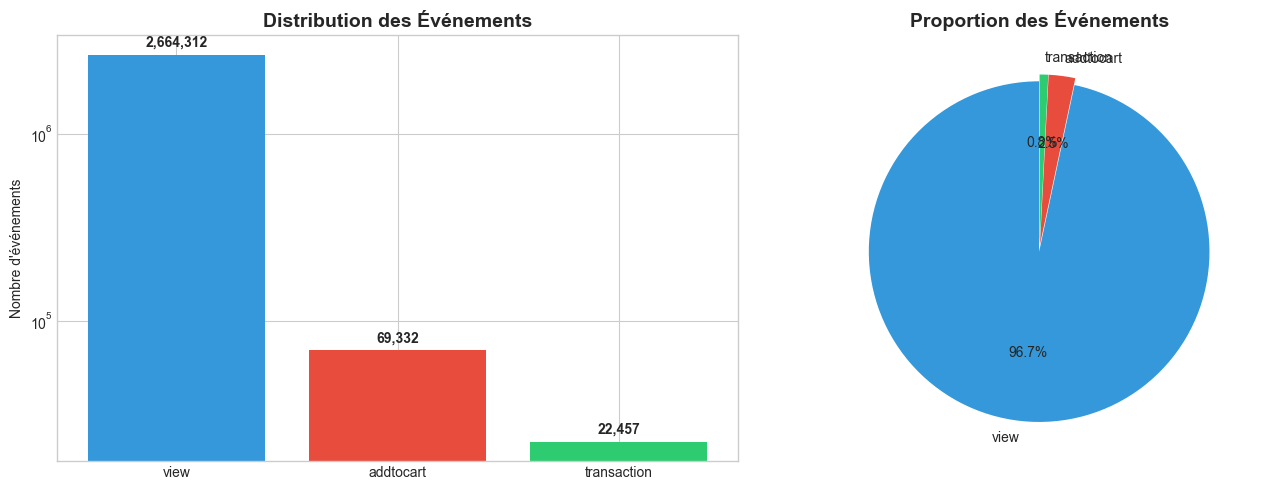

In [83]:
# Répartition des types d'événements
event_counts = events['event'].value_counts()
event_pct = events['event'].value_counts(normalize=True) * 100

print(" RÉPARTITION DES ÉVÉNEMENTS")
print("=" * 50)
for event_type in event_counts.index:
    print(f"   {event_type.upper():15} : {event_counts[event_type]:>10,} ({event_pct[event_type]:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#3498db', '#e74c3c', '#2ecc71']
axes[0].bar(event_counts.index, event_counts.values, color=colors)
axes[0].set_title('Distribution des Événements', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre d\'événements')
axes[0].set_yscale('log')
for i, v in enumerate(event_counts.values):
    axes[0].text(i, v*1.1, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(event_counts.values, labels=event_counts.index, autopct='%1.1f%%', 
            colors=colors, explode=(0.02, 0.02, 0.02), startangle=90)
axes[1].set_title('Proportion des Événements', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_distribution_events.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Analyse Temporelle

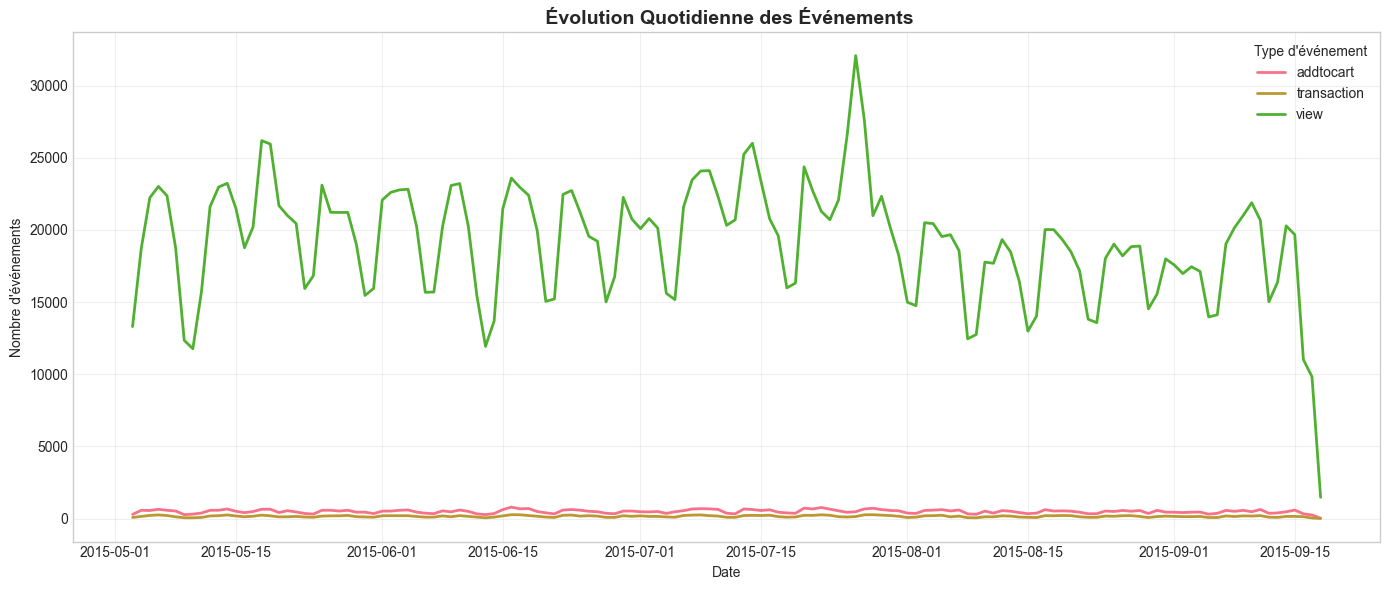

In [84]:
# Évolution quotidienne des événements
daily_events = events.groupby(['date', 'event']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
daily_events.plot(ax=ax, linewidth=2)
ax.set_title(' Évolution Quotidienne des Événements', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Nombre d\'événements')
ax.legend(title='Type d\'événement')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_evolution_quotidienne.png', dpi=150, bbox_inches='tight')
plt.show()

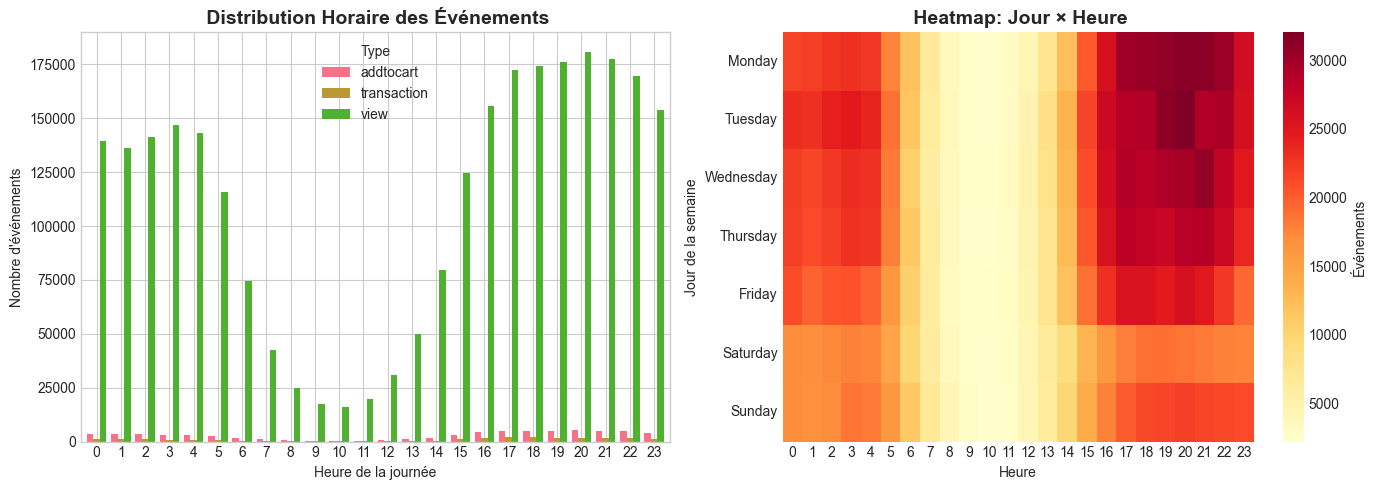

In [85]:
# Analyse par heure de la journée
hourly_events = events.groupby(['hour', 'event']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique par type d'événement
hourly_events.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title(' Distribution Horaire des Événements', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Nombre d\'événements')
axes[0].legend(title='Type')
axes[0].tick_params(axis='x', rotation=0)

# Heatmap jour/heure
events['day_num'] = events['datetime'].dt.dayofweek
heatmap_data = events.pivot_table(index='day_num', columns='hour', values='visitorid', aggfunc='count')
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data.index = days_order

sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Événements'})
axes[1].set_title(' Heatmap: Jour × Heure', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Jour de la semaine')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_analyse_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

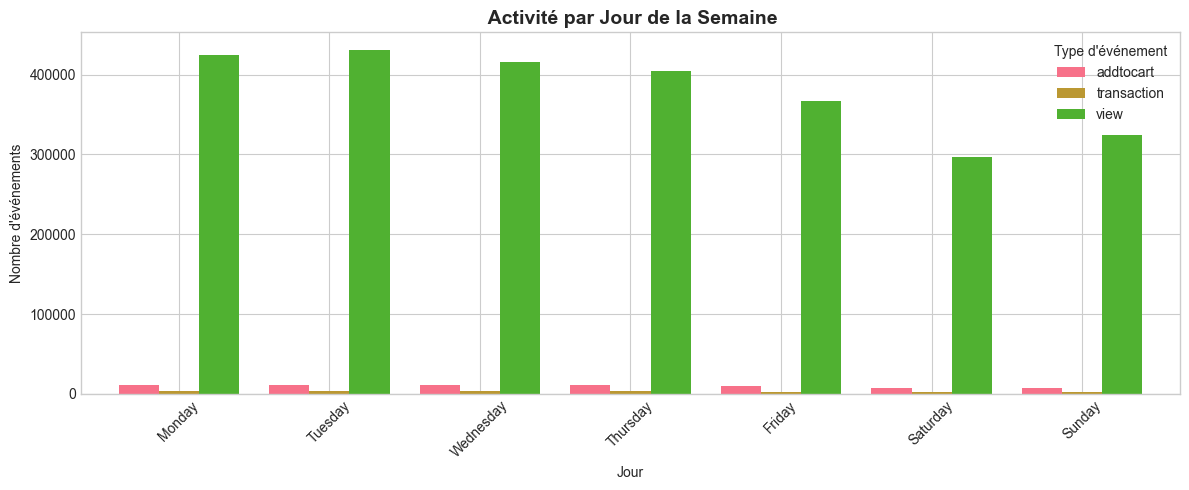

In [86]:
# Analyse par jour de la semaine
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_events = events.groupby(['day_of_week', 'event']).size().unstack(fill_value=0)
weekly_events = weekly_events.reindex(day_order)

fig, ax = plt.subplots(figsize=(12, 5))
weekly_events.plot(kind='bar', ax=ax, width=0.8)
ax.set_title(' Activité par Jour de la Semaine', fontsize=14, fontweight='bold')
ax.set_xlabel('Jour')
ax.set_ylabel('Nombre d\'événements')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type d\'événement')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_activite_semaine.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Analyse du Funnel de Conversion 

In [87]:
# Calcul des KPIs du funnel
views = event_counts.get('view', 0)
add_to_cart = event_counts.get('addtocart', 0)
transactions = event_counts.get('transaction', 0)

# Taux de conversion
view_to_cart_rate = (add_to_cart / views) * 100
cart_to_purchase_rate = (transactions / add_to_cart) * 100
overall_conversion_rate = (transactions / views) * 100
cart_abandonment_rate = 100 - cart_to_purchase_rate

print(" FUNNEL DE CONVERSION - KPIs")
print("=" * 60)
print(f"\n ÉTAPES DU FUNNEL:")
print(f"   1. Vues produits        : {views:>12,}")
print(f"   2. Ajouts au panier     : {add_to_cart:>12,}")
print(f"   3. Transactions         : {transactions:>12,}")

print(f"\n TAUX DE CONVERSION:")
print(f"   • Vue → Panier          : {view_to_cart_rate:>8.2f}%")
print(f"   • Panier → Achat        : {cart_to_purchase_rate:>8.2f}%")
print(f"   • Conversion globale    : {overall_conversion_rate:>8.2f}%")

print(f"\n  TAUX D'ABANDON PANIER  : {cart_abandonment_rate:.2f}%")

 FUNNEL DE CONVERSION - KPIs

 ÉTAPES DU FUNNEL:
   1. Vues produits        :    2,664,312
   2. Ajouts au panier     :       69,332
   3. Transactions         :       22,457

 TAUX DE CONVERSION:
   • Vue → Panier          :     2.60%
   • Panier → Achat        :    32.39%
   • Conversion globale    :     0.84%

  TAUX D'ABANDON PANIER  : 67.61%


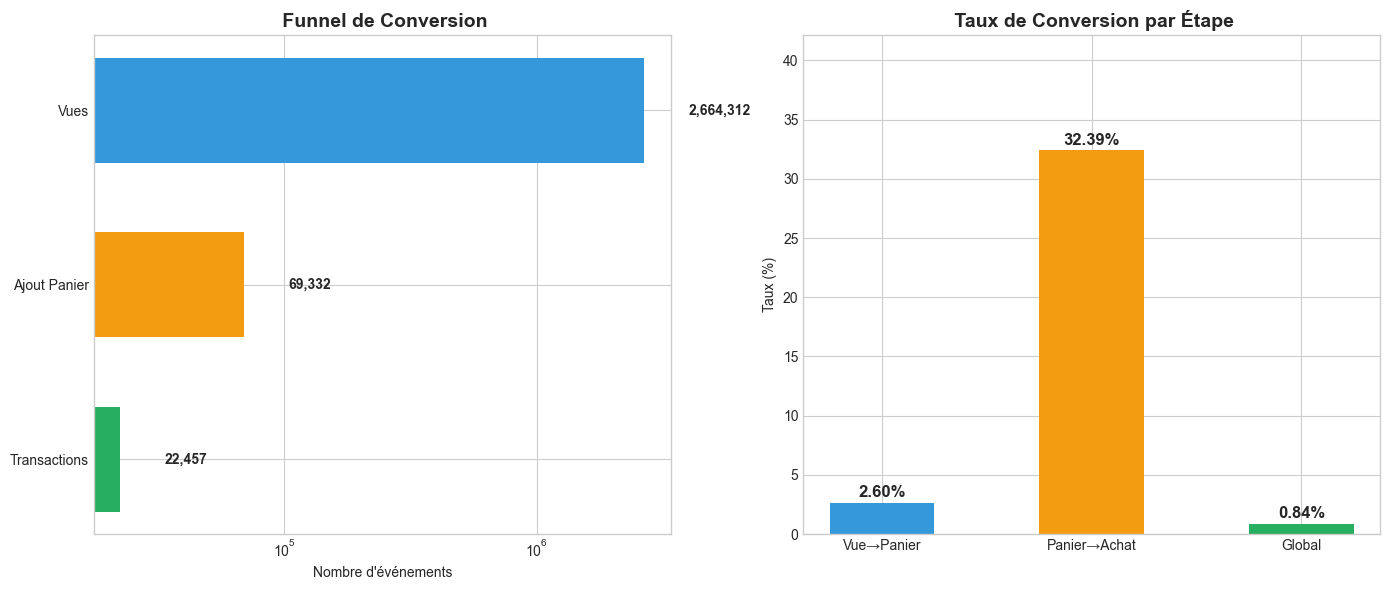

In [88]:
from matplotlib.patches import FancyBboxPatch

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Funnel bar chart
stages = ['Vues', 'Ajout Panier', 'Transactions']
values = [views, add_to_cart, transactions]
colors = ['#3498db', '#f39c12', '#27ae60']

bars = axes[0].barh(stages[::-1], values[::-1], color=colors[::-1], height=0.6)
axes[0].set_title(' Funnel de Conversion', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre d\'événements')
axes[0].set_xscale('log')

for bar, val in zip(bars, values[::-1]):
    axes[0].text(val * 1.5, bar.get_y() + bar.get_height()/2, 
                 f'{val:,}', va='center', fontweight='bold')

# Taux de conversion entre étapes
conversion_stages = ['Vue→Panier', 'Panier→Achat', 'Global']
conversion_rates = [view_to_cart_rate, cart_to_purchase_rate, overall_conversion_rate]
colors_conv = ['#3498db', '#f39c12', '#27ae60']

bars2 = axes[1].bar(conversion_stages, conversion_rates, color=colors_conv, width=0.5)
axes[1].set_title(' Taux de Conversion par Étape', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Taux (%)')
axes[1].set_ylim(0, max(conversion_rates) * 1.3)

for bar, rate in zip(bars2, conversion_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{rate:.2f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_funnel_conversion.png', dpi=150, bbox_inches='tight')
plt.show()

 SEGMENTATION DES VISITEURS
   Browsers        :  1,368,715 (97.2%)
   Cart Adders     :     27,146 (1.9%)
   Buyers          :     11,719 (0.8%)


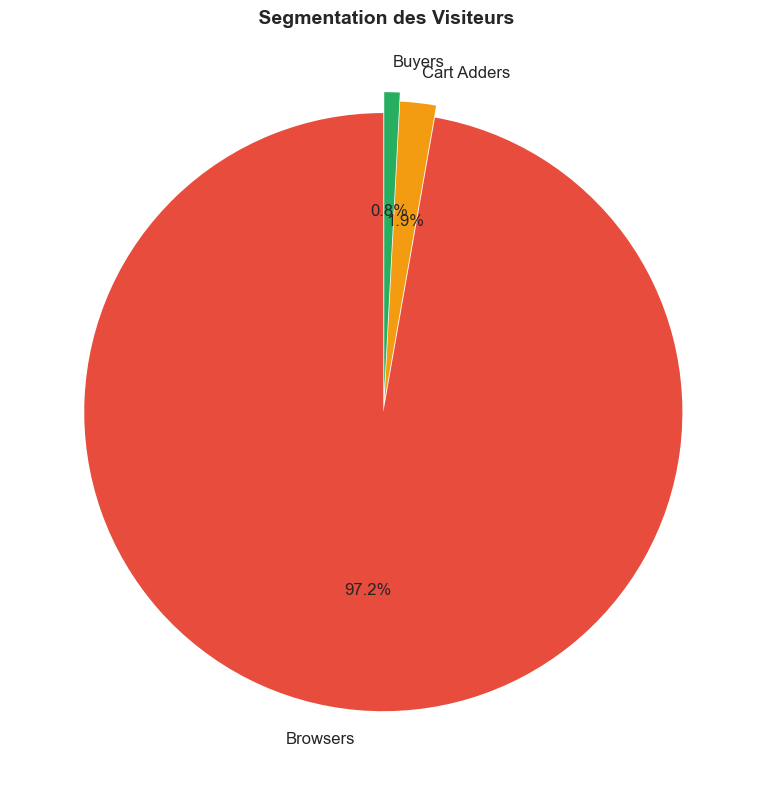

In [89]:
visitor_journey = events.groupby('visitorid')['event'].value_counts().unstack(fill_value=0)

# Segmentation des visiteurs
visitor_journey['segment'] = 'Browsers'  # Par défaut
visitor_journey.loc[visitor_journey['addtocart'] > 0, 'segment'] = 'Cart Adders'
visitor_journey.loc[visitor_journey['transaction'] > 0, 'segment'] = 'Buyers'

segment_counts = visitor_journey['segment'].value_counts()

print(" SEGMENTATION DES VISITEURS")
print("=" * 50)
for segment in ['Browsers', 'Cart Adders', 'Buyers']:
    count = segment_counts.get(segment, 0)
    pct = (count / len(visitor_journey)) * 100
    print(f"   {segment:15} : {count:>10,} ({pct:.1f}%)")

# Visualisation
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['#e74c3c', '#f39c12', '#27ae60']
explode = (0.02, 0.02, 0.05)

ax.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
       colors=colors, explode=explode, startangle=90, textprops={'fontsize': 12})
ax.set_title(' Segmentation des Visiteurs', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_segmentation_visiteurs.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Analyse Catalogue & Catégories 

In [90]:
item_categories = item_props[item_props['property'] == 'categoryid'][['itemid', 'value']]
item_categories.columns = ['itemid', 'categoryid']
item_categories['categoryid'] = pd.to_numeric(item_categories['categoryid'], errors='coerce')

# Joindre avec les events
events_with_cat = events.merge(item_categories, on='itemid', how='left')

print(f" Événements enrichis avec catégories: {len(events_with_cat):,}")
print(f"   Produits avec catégorie: {events_with_cat['categoryid'].notna().sum():,}")

 Événements enrichis avec catégories: 2,875,156
   Produits avec catégorie: 270,546


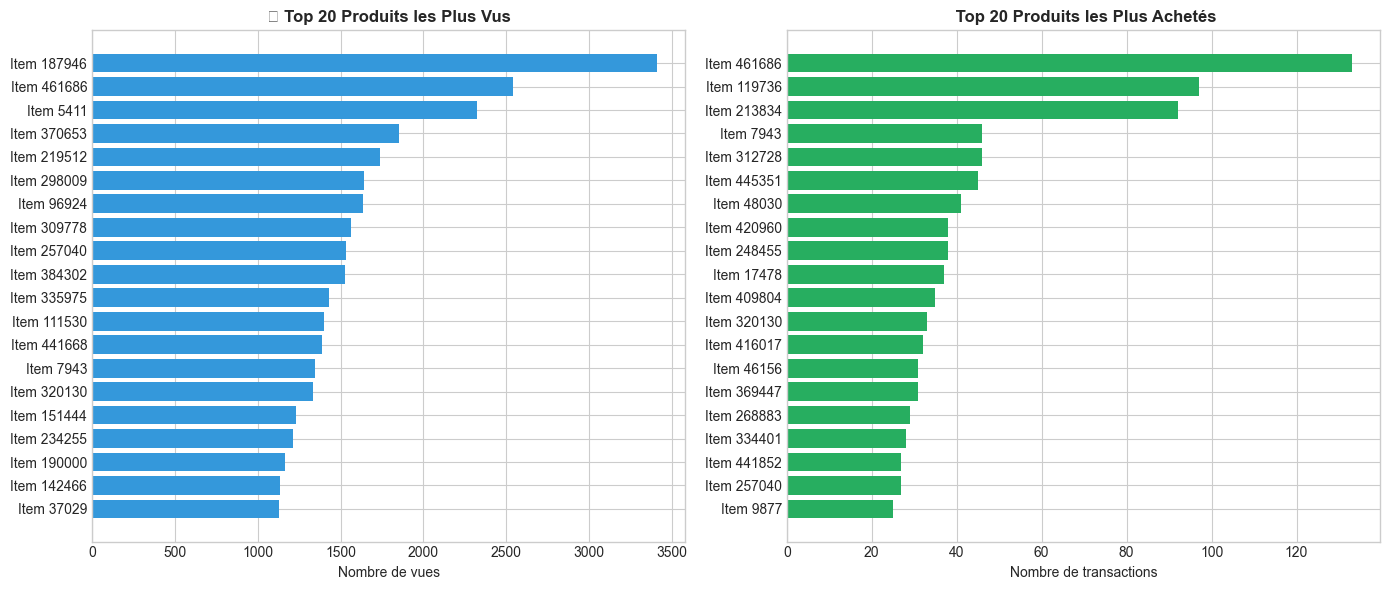

In [91]:
# Top 20 produits les plus vus
top_viewed = events[events['event'] == 'view']['itemid'].value_counts().head(20)

# Top 20 produits les plus achetés
top_purchased = events[events['event'] == 'transaction']['itemid'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top vus
axes[0].barh(range(len(top_viewed)), top_viewed.values, color='#3498db')
axes[0].set_yticks(range(len(top_viewed)))
axes[0].set_yticklabels([f'Item {i}' for i in top_viewed.index])
axes[0].set_title('👀 Top 20 Produits les Plus Vus', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nombre de vues')
axes[0].invert_yaxis()

# Top achetés
axes[1].barh(range(len(top_purchased)), top_purchased.values, color='#27ae60')
axes[1].set_yticks(range(len(top_purchased)))
axes[1].set_yticklabels([f'Item {i}' for i in top_purchased.index])
axes[1].set_title(' Top 20 Produits les Plus Achetés', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Nombre de transactions')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/07_top_produits.png', dpi=150, bbox_inches='tight')
plt.show()

In [92]:
# Analyse de la conversion par produit
product_funnel = events.groupby('itemid')['event'].value_counts().unstack(fill_value=0)
product_funnel.columns = [col if col != 'view' else 'views' for col in product_funnel.columns]

# Produits avec le meilleur taux de conversion
product_funnel['conversion_rate'] = (product_funnel.get('transaction', 0) / product_funnel.get('views', 1)) * 100

# Filtrer produits avec au moins 100 vues pour significativité
significant_products = product_funnel[product_funnel['views'] >= 100]
top_converting = significant_products.nlargest(20, 'conversion_rate')

print(" TOP 20 PRODUITS - MEILLEUR TAUX DE CONVERSION")
print("(Minimum 100 vues pour significativité)")
print("=" * 60)
print(top_converting[['views', 'transaction', 'conversion_rate']].head(10).to_string())

 TOP 20 PRODUITS - MEILLEUR TAUX DE CONVERSION
(Minimum 100 vues pour significativité)
        views  transaction  conversion_rate
itemid                                     
213834    293           92            31.40
334401    200           28            14.00
119736    752           97            12.90
140527    111           12            10.81
256146    130           14            10.77
220513    101           10             9.90
246532    113           11             9.73
288525    178           16             8.99
174489    146           13             8.90
92466     181           16             8.84


## 6. Segmentation Comportementale

In [93]:
# Créer un profil visiteur
visitor_profile = events.groupby('visitorid').agg({
    'event': 'count',  # Total événements
    'itemid': 'nunique',  # Produits uniques consultés
    'datetime': ['min', 'max'],  # Première et dernière visite
}).reset_index()

visitor_profile.columns = ['visitorid', 'total_events', 'unique_items', 'first_visit', 'last_visit']

# Ajouter les compteurs par type d'événement
event_pivot = events.pivot_table(index='visitorid', columns='event', aggfunc='size', fill_value=0)
visitor_profile = visitor_profile.merge(event_pivot.reset_index(), on='visitorid')

# Calculer des métriques dérivées
visitor_profile['session_duration'] = (visitor_profile['last_visit'] - visitor_profile['first_visit']).dt.total_seconds() / 60
visitor_profile['add_to_cart_rate'] = visitor_profile['addtocart'] / visitor_profile['view'] * 100
visitor_profile['purchase_rate'] = visitor_profile['transaction'] / visitor_profile['view'] * 100

print(" PROFIL VISITEUR - Statistiques")
visitor_profile.describe().round(2)

 PROFIL VISITEUR - Statistiques


,visitorid,total_events,unique_items,first_visit,last_visit,addtocart,transaction,view,session_duration,add_to_cart_rate,purchase_rate
count,1407580.00,1407580.00,1407580.00,1407580,1407580,1407580.00,1407580.00,1407580.00,1407580.00,1407500.00,1404607.00
mean,703789.50,1.96,1.52,2015-07-09 10:16:42.513630208,2015-07-11 19:17:24.858687232,0.05,0.02,1.89,3420.71,inf,inf
min,0.00,1.00,1.00,2015-05-03 03:00:04.384000,2015-05-03 03:00:11.289000,0.00,0.00,0.00,0.00,0.00,0.00
25%,351894.75,1.00,1.00,2015-06-04 21:48:25.778250240,2015-06-08 00:56:58.077500160,0.00,0.00,1.00,0.00,0.00,0.00
50%,703789.50,1.00,1.00,2015-07-10 10:54:21.271000064,2015-07-13 01:08:21.987500032,0.00,0.00,1.00,0.00,0.00,0.00
75%,1055684.25,2.00,1.00,2015-08-11 00:00:35.832500224,2015-08-13 16:42:47.900000,0.00,0.00,2.00,0.78,0.00,0.00
max,1407579.00,7757.00,3814.00,2015-09-18 02:59:41.778000,2015-09-18 02:59:47.788000,719.00,559.00,6479.00,198680.92,inf,inf
std,406333.49,12.58,7.14,NaN,NaN,1.17,0.83,10.99,16748.37,NaN,NaN


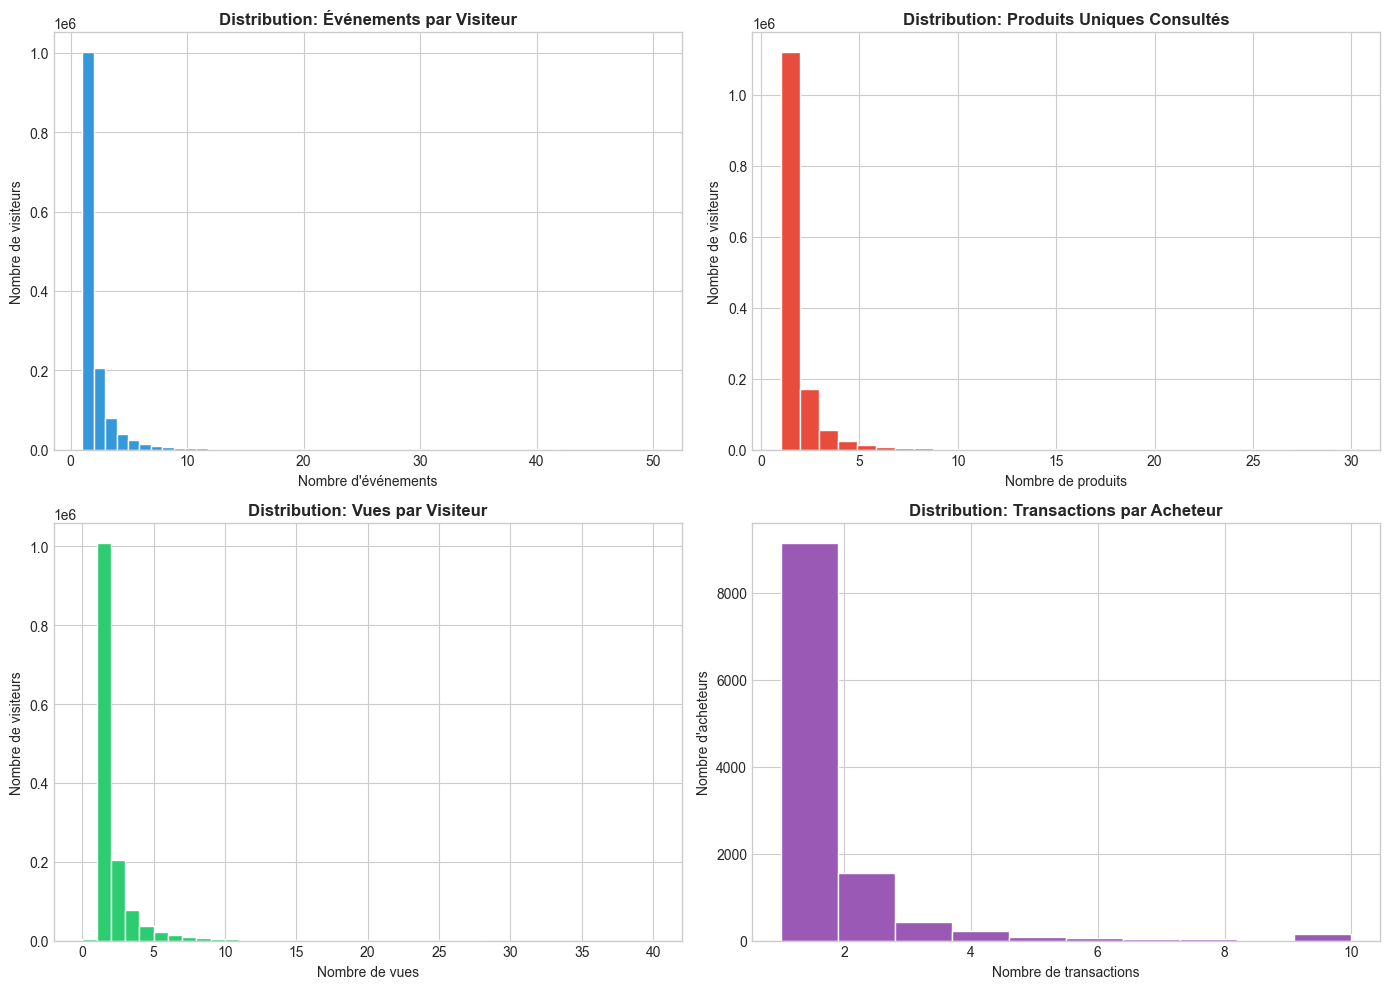

In [94]:
# Distribution des visiteurs par nombre d'événements
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution du nombre d'événements
axes[0, 0].hist(visitor_profile['total_events'].clip(upper=50), bins=50, color='#3498db', edgecolor='white')
axes[0, 0].set_title('Distribution: Événements par Visiteur', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nombre d\'événements')
axes[0, 0].set_ylabel('Nombre de visiteurs')

# Distribution du nombre de produits consultés
axes[0, 1].hist(visitor_profile['unique_items'].clip(upper=30), bins=30, color='#e74c3c', edgecolor='white')
axes[0, 1].set_title('Distribution: Produits Uniques Consultés', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de produits')
axes[0, 1].set_ylabel('Nombre de visiteurs')

# Distribution des vues
axes[1, 0].hist(visitor_profile['view'].clip(upper=40), bins=40, color='#2ecc71', edgecolor='white')
axes[1, 0].set_title('Distribution: Vues par Visiteur', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Nombre de vues')
axes[1, 0].set_ylabel('Nombre de visiteurs')

# Distribution des achats
buyers = visitor_profile[visitor_profile['transaction'] > 0]
axes[1, 1].hist(buyers['transaction'].clip(upper=10), bins=10, color='#9b59b6', edgecolor='white')
axes[1, 1].set_title('Distribution: Transactions par Acheteur', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Nombre de transactions')
axes[1, 1].set_ylabel('Nombre d\'acheteurs')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/08_distribution_visiteurs.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Tableau de Bord - Synthèse des KPIs 

In [95]:
# Création du tableau de synthèse des KPIs
print(" TABLEAU DE BORD - SYNTHÈSE DES KPIs E-COMMERCE")

print("\n MÉTRIQUES DE TRAFIC")
print(f"   Visiteurs uniques          : {unique_visitors:>15,}")
print(f"   Total événements           : {total_events:>15,}")
print(f"   Événements/visiteur (moy.) : {total_events/unique_visitors:>15.1f}")
print(f"   Produits consultés         : {unique_items:>15,}")

print("\n MÉTRIQUES DE CONVERSION")
print(f"   Vues produits              : {views:>15,}")
print(f"   Ajouts panier              : {add_to_cart:>15,}")
print(f"   Transactions               : {transactions:>15,}")
print(f"   Taux Vue -> Panier         : {view_to_cart_rate:>14.2f}%")
print(f"   Taux Panier -> Achat       : {cart_to_purchase_rate:>14.2f}%")
print(f"   Taux Conversion Global     : {overall_conversion_rate:>14.2f}%")
print(f"   Taux Abandon Panier        : {cart_abandonment_rate:>14.2f}%")

print("\n SEGMENTATION VISITEURS")
for segment in ['Browsers', 'Cart Adders', 'Buyers']:
    count = segment_counts.get(segment, 0)
    pct = (count / len(visitor_journey)) * 100
    print(f"   {segment:25} : {count:>10,} ({pct:>5.1f}%)")


 TABLEAU DE BORD - SYNTHÈSE DES KPIs E-COMMERCE

 MÉTRIQUES DE TRAFIC
   Visiteurs uniques          :       1,407,580
   Total événements           :       2,756,101
   Événements/visiteur (moy.) :             2.0
   Produits consultés         :         235,061

 MÉTRIQUES DE CONVERSION
   Vues produits              :       2,664,312
   Ajouts panier              :          69,332
   Transactions               :          22,457
   Taux Vue -> Panier         :           2.60%
   Taux Panier -> Achat       :          32.39%
   Taux Conversion Global     :           0.84%
   Taux Abandon Panier        :          67.61%

 SEGMENTATION VISITEURS
   Browsers                  :  1,368,715 ( 97.2%)
   Cart Adders               :     27,146 (  1.9%)
   Buyers                    :     11,719 (  0.8%)


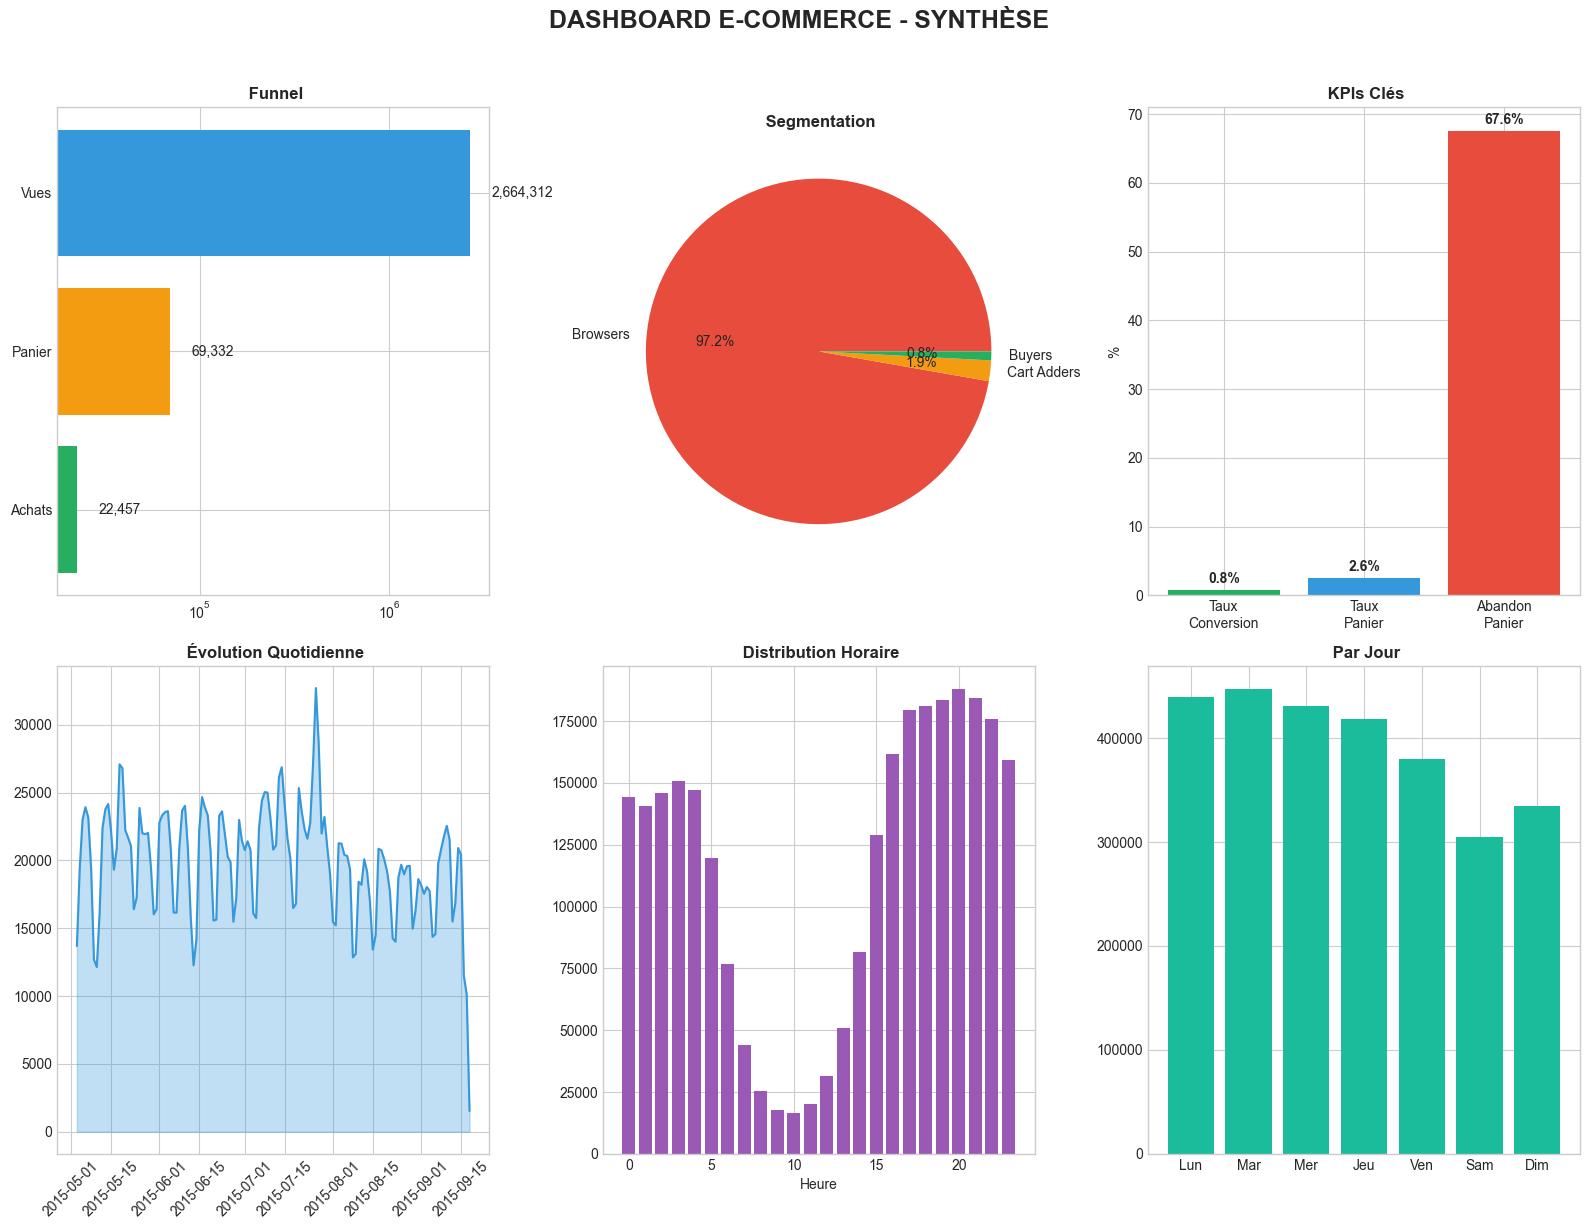

In [96]:
# Dashboard visuel récapitulatif
fig = plt.figure(figsize=(16, 12))

# Titre principal
fig.suptitle(' DASHBOARD E-COMMERCE - SYNTHÈSE', fontsize=18, fontweight='bold', y=1.02)

# 1. Funnel de conversion
ax1 = fig.add_subplot(2, 3, 1)
stages = ['Vues', 'Panier', 'Achats']
values = [views, add_to_cart, transactions]
colors = ['#3498db', '#f39c12', '#27ae60']
ax1.barh(stages[::-1], values[::-1], color=colors[::-1])
ax1.set_title(' Funnel', fontweight='bold')
ax1.set_xscale('log')
for i, v in enumerate(values[::-1]):
    ax1.text(v*1.3, i, f'{v:,}', va='center')

# 2. Segmentation
ax2 = fig.add_subplot(2, 3, 2)
ax2.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=['#e74c3c', '#f39c12', '#27ae60'])
ax2.set_title(' Segmentation', fontweight='bold')

# 3. KPIs clés
ax3 = fig.add_subplot(2, 3, 3)
kpi_names = ['Taux\nConversion', 'Taux\nPanier', 'Abandon\nPanier']
kpi_values = [overall_conversion_rate, view_to_cart_rate, cart_abandonment_rate]
colors_kpi = ['#27ae60', '#3498db', '#e74c3c']
bars = ax3.bar(kpi_names, kpi_values, color=colors_kpi)
ax3.set_title(' KPIs Clés', fontweight='bold')
ax3.set_ylabel('%')
for bar, val in zip(bars, kpi_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontweight='bold')

# 4. Évolution temporelle
ax4 = fig.add_subplot(2, 3, 4)
daily_total = events.groupby('date').size()
ax4.plot(daily_total.index, daily_total.values, color='#3498db', linewidth=1.5)
ax4.fill_between(daily_total.index, daily_total.values, alpha=0.3, color='#3498db')
ax4.set_title(' Évolution Quotidienne', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

# 5. Distribution horaire
ax5 = fig.add_subplot(2, 3, 5)
hourly_total = events.groupby('hour').size()
ax5.bar(hourly_total.index, hourly_total.values, color='#9b59b6')
ax5.set_title(' Distribution Horaire', fontweight='bold')
ax5.set_xlabel('Heure')

# 6. Distribution par jour de semaine
ax6 = fig.add_subplot(2, 3, 6)
weekly_total = events.groupby('day_of_week').size().reindex(day_order)
ax6.bar(range(7), weekly_total.values, color='#1abc9c')
ax6.set_xticks(range(7))
ax6.set_xticklabels(['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim'])
ax6.set_title(' Par Jour', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/09_dashboard_synthese.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Conclusions et Recommandations 

In [97]:
# Génération automatique des insights
print(" CONCLUSIONS ET RECOMMANDATIONS")

print("\n INSIGHTS CLÉS:")

# Insight 1: Conversion
print(f"\n1. CONVERSION: Le taux de conversion global est de {overall_conversion_rate:.2f}%")
if overall_conversion_rate < 1:
    print("    Ce taux est en dessous du benchmark e-commerce (1-3%)")
    print("   -> Actions: Optimiser les fiches produits, améliorer le checkout")
elif overall_conversion_rate < 3:
    print("    Taux dans la moyenne du marché e-commerce")
else:
    print("   Excellent taux de conversion!")

# Insight 2: Abandon panier
print(f"\n2. ABANDON PANIER: {cart_abandonment_rate:.1f}% des paniers sont abandonnés")
if cart_abandonment_rate > 70:
    print("   Taux d'abandon élevé (benchmark: 60-70%)")
    print("   -> Actions: Email de relance panier, checkout simplifié, transparence frais")
else:
    print("   Taux d'abandon dans la normale")

# Insight 3: Segmentation
buyers_pct = (segment_counts.get('Buyers', 0) / len(visitor_journey)) * 100
print(f"\n3. SEGMENTATION: Seulement {buyers_pct:.1f}% des visiteurs sont acheteurs")
print("   -> Actions: Personnalisation, retargeting, programme fidélité")

print("\n RECOMMANDATIONS PRIORITAIRES:")
print("""\n   1. Optimiser le processus de checkout
      - Réduire le nombre d'étapes
      - Proposer le guest checkout
      - Afficher clairement les frais de livraison

   2. Mettre en place des emails de relance panier abandonné
      - Email J+1 avec rappel des produits
      - Offre promotionnelle J+3

   3. Analyser l'expérience mobile
      - Optimiser les temps de chargement
      - Simplifier la navigation

   4. Développer la personnalisation
      - Recommandations produits basées sur l'historique
      - Cross-selling et up-selling ciblés

   5. Approfondir l'analyse par catégorie
      - Identifier les catégories sous-performantes
      - Optimiser le merchandising des top catégories
""")

print(" FIN DE L'ANALYSE")

 CONCLUSIONS ET RECOMMANDATIONS

 INSIGHTS CLÉS:

1. CONVERSION: Le taux de conversion global est de 0.84%
    Ce taux est en dessous du benchmark e-commerce (1-3%)
   -> Actions: Optimiser les fiches produits, améliorer le checkout

2. ABANDON PANIER: 67.6% des paniers sont abandonnés
   Taux d'abandon dans la normale

3. SEGMENTATION: Seulement 0.8% des visiteurs sont acheteurs
   -> Actions: Personnalisation, retargeting, programme fidélité

 RECOMMANDATIONS PRIORITAIRES:

   1. Optimiser le processus de checkout
      - Réduire le nombre d'étapes
      - Proposer le guest checkout
      - Afficher clairement les frais de livraison

   2. Mettre en place des emails de relance panier abandonné
      - Email J+1 avec rappel des produits
      - Offre promotionnelle J+3

   3. Analyser l'expérience mobile
      - Optimiser les temps de chargement
      - Simplifier la navigation

   4. Développer la personnalisation
      - Recommandations produits basées sur l'historique
      - Cross

In [98]:
# Export des résultats clés
summary_data = {
    'Métrique': [
        'Visiteurs uniques',
        'Total événements', 
        'Produits consultés',
        'Transactions',
        'Taux conversion global (%)',
        'Taux ajout panier (%)',
        'Taux abandon panier (%)',
        'Période analyse (jours)'
    ],
    'Valeur': [
        unique_visitors,
        total_events,
        unique_items,
        transactions,
        round(overall_conversion_rate, 2),
        round(view_to_cart_rate, 2),
        round(cart_abandonment_rate, 2),
        (events['datetime'].max() - events['datetime'].min()).days
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv('kpi_summary.csv', index=False)
print(" Résumé KPIs exporté: kpi_summary.csv")

summary_df

 Résumé KPIs exporté: kpi_summary.csv


,Métrique,Valeur
0,Visiteurs uniques,1407580.00
1,Total événements,2756101.00
2,Produits consultés,235061.00
3,Transactions,22457.00
4,Taux conversion global (%),0.84
5,Taux ajout panier (%),2.60
6,Taux abandon panier (%),67.61
7,Période analyse (jours),137.00
